<a href="https://colab.research.google.com/github/MamidiPravallikaReddy/DL_LAB/blob/main/DL_week7ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--2026-03-30 14:53:57--  http://ufldl.stanford.edu/housenumbers/train_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182040794 (174M) [text/plain]
Saving to: ‘train_32x32.mat’

train_32x32.mat     100%[===================>] 173.61M  54.9MB/s    in 3.3s    

2026-03-30 14:54:00 (52.4 MB/s) - ‘train_32x32.mat’ saved [182040794/182040794]

--2026-03-30 14:54:00--  http://ufldl.stanford.edu/housenumbers/test_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64275384 (61M) [text/plain]
Saving to: ‘test_32x32.mat’

test_32x32.mat      100%[===================>]  61.30M  36.5MB/s    in 1.7s    

2026-03-30 14:54:02 (36.5 MB/s) - ‘test_32x32.mat’ saved [64275384/64

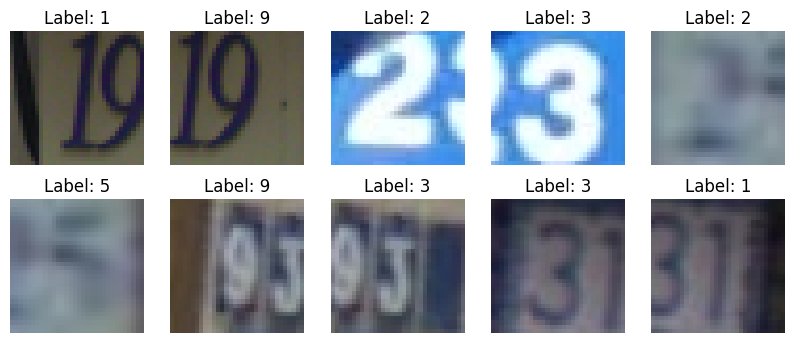

In [2]:
import keras
import keras.utils
from keras import layers, models
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np
import scipy.io

# Download Dataset
!wget http://ufldl.stanford.edu/housenumbers/train_32x32.mat
!wget http://ufldl.stanford.edu/housenumbers/test_32x32.mat

train_data = scipy.io.loadmat('train_32x32.mat')
test_data = scipy.io.loadmat('test_32x32.mat')

x_train = train_data['X']
y_train = train_data['y']

x_test = test_data['X']
y_test = test_data['y']

x_train = np.transpose(x_train, (3,0,1,2))
x_test = np.transpose(x_test, (3,0,1,2))

y_train[y_train == 10] = 0
y_test[y_test == 10] = 0

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(f"Label: {y_train[i][0]}")
    plt.axis('off')
plt.show()

x_train_main = x_train[:60000]
y_train_main = y_train[:60000]

x_val = x_train[60000:]
y_val = y_train[60000:]

x_train_main = x_train_main / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

**LeNet**

In [3]:
LeNet_Model = Sequential()

LeNet_Model.add(Conv2D(6,(5,5),activation='tanh',input_shape=(32,32,3)))
LeNet_Model.add(AveragePooling2D((2,2)))

LeNet_Model.add(Conv2D(16,(5,5),activation='tanh'))
LeNet_Model.add(AveragePooling2D((2,2)))

LeNet_Model.add(Flatten())
LeNet_Model.add(Dense(120,activation='tanh'))
LeNet_Model.add(Dense(84,activation='tanh'))
LeNet_Model.add(Dense(10,activation='softmax'))

LeNet_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

LeNet_Model.fit(x_train_main, y_train_main, epochs=5, batch_size=128, validation_data=(x_val, y_val))

LeNet_Model.evaluate(x_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.2198 - loss: 2.2054 - val_accuracy: 0.2727 - val_loss: 2.1585
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.5798 - loss: 1.3374 - val_accuracy: 0.7475 - val_loss: 0.8302
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 84ms/step - accuracy: 0.7922 - loss: 0.6894 - val_accuracy: 0.8070 - val_loss: 0.6330
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 82ms/step - accuracy: 0.8320 - loss: 0.5569 - val_accuracy: 0.8363 - val_loss: 0.5556
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - accuracy: 0.8519 - loss: 0.4883 - val_accuracy: 0.8399 - val_loss: 0.5292
814/814 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8153 - loss: 0.6181


[0.6181296110153198, 0.8152658343315125]

**AlexNet**

In [4]:
AlexNet_Model = Sequential()

AlexNet_Model.add(Conv2D(96,(3,3),activation='relu',input_shape=(32,32,3)))
AlexNet_Model.add(MaxPooling2D((2,2)))

AlexNet_Model.add(Conv2D(256,(3,3),activation='relu'))
AlexNet_Model.add(MaxPooling2D((2,2)))

AlexNet_Model.add(Conv2D(384,(3,3),activation='relu'))

AlexNet_Model.add(Flatten())
AlexNet_Model.add(Dense(1024,activation='relu'))
AlexNet_Model.add(Dropout(0.5))
AlexNet_Model.add(Dense(10,activation='softmax'))

AlexNet_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

AlexNet_Model.fit(x_train_main, y_train_main, epochs=5, batch_size=128, validation_data=(x_val, y_val))

AlexNet_Model.evaluate(x_test, y_test)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 629s 1s/step - accuracy: 0.6333 - loss: 1.1016 - val_accuracy: 0.8528 - val_loss: 0.5098
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 625s 1s/step - accuracy: 0.8690 - loss: 0.4407 - val_accuracy: 0.8858 - val_loss: 0.3901
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 676s 1s/step - accuracy: 0.8958 - loss: 0.3524 - val_accuracy: 0.9025 - val_loss: 0.3321
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 616s 1s/step - accuracy: 0.9117 - loss: 0.2986 - val_accuracy: 0.9152 - val_loss: 0.3094
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 642s 1s/step - accuracy: 0.9244 - loss: 0.2596 - val_accuracy: 0.9222 - val_loss: 0.2833
814/814 ━━━━━━━━━━━━━━━━━━━━ 67s 83ms/step - accuracy: 0.9165 - loss: 0.3005


[0.30049923062324524, 0.9165258407592773]

**ZF-Net**

In [3]:
ZFNet_Model = Sequential()

ZFNet_Model.add(Conv2D(96,(7,7),activation='relu',input_shape=(32,32,3)))
ZFNet_Model.add(MaxPooling2D((2,2)))

ZFNet_Model.add(Conv2D(256,(5,5),activation='relu'))
ZFNet_Model.add(MaxPooling2D((2,2)))

ZFNet_Model.add(Conv2D(384,(3,3),activation='relu'))

ZFNet_Model.add(Flatten())
ZFNet_Model.add(Dense(1024,activation='relu'))
ZFNet_Model.add(Dense(10,activation='softmax'))

ZFNet_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

ZFNet_Model.fit(x_train_main, y_train_main, epochs=5, batch_size=128, validation_data=(x_val, y_val))

ZFNet_Model.evaluate(x_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.6126 - loss: 1.1652 - val_accuracy: 0.8285 - val_loss: 0.5659
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8577 - loss: 0.4694 - val_accuracy: 0.8728 - val_loss: 0.4245
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8888 - loss: 0.3680 - val_accuracy: 0.8874 - val_loss: 0.3755
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9068 - loss: 0.3141 - val_accuracy: 0.8866 - val_loss: 0.3970
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9201 - loss: 0.2677 - val_accuracy: 0.8976 - val_loss: 0.3485
814/814 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8844 - loss: 0.3942


[0.39417290687561035, 0.8844115138053894]

**VGGNet**

In [7]:
VGG_Model = Sequential()

VGG_Model.add(Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
VGG_Model.add(Conv2D(32,(3,3),activation='relu'))
VGG_Model.add(MaxPooling2D((2,2)))

VGG_Model.add(Conv2D(64,(3,3),activation='relu'))
VGG_Model.add(Conv2D(64,(3,3),activation='relu'))

VGG_Model.add(Conv2D(128,(3,3),activation='relu'))
VGG_Model.add(Conv2D(128,(3,3),activation='relu'))
VGG_Model.add(MaxPooling2D((2,2)))
VGG_Model.add(Flatten())
VGG_Model.add(Dense(256,activation='relu'))
VGG_Model.add(Dropout(0.5))
VGG_Model.add(Dense(10,activation='softmax'))

VGG_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

VGG_Model.fit(x_train_main, y_train_main, epochs=5, batch_size=128, validation_data=(x_val, y_val))

VGG_Model.evaluate(x_test, y_test)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.5772 - loss: 1.2468 - val_accuracy: 0.8478 - val_loss: 0.5029
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8561 - loss: 0.4825 - val_accuracy: 0.8796 - val_loss: 0.3988
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8851 - loss: 0.3867 - val_accuracy: 0.9039 - val_loss: 0.3244
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9022 - loss: 0.3370 - val_accuracy: 0.9093 - val_loss: 0.3070
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9104 - loss: 0.3037 - val_accuracy: 0.9170 - val_loss: 0.2899
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9082 - loss: 0.3178


[0.31778743863105774, 0.9081515073776245]

**GoogLeNet**

In [8]:
GoogleNet_Model = Sequential()

GoogleNet_Model.add(Conv2D(64,(3,3),activation='relu',input_shape=(32,32,3)))
GoogleNet_Model.add(MaxPooling2D((2,2)))

GoogleNet_Model.add(Conv2D(128,(3,3),activation='relu'))
GoogleNet_Model.add(MaxPooling2D((2,2)))

GoogleNet_Model.add(Flatten())
GoogleNet_Model.add(Dense(256,activation='relu'))
GoogleNet_Model.add(Dense(10,activation='softmax'))

GoogleNet_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

GoogleNet_Model.fit(x_train_main, y_train_main, epochs=5, batch_size=128, validation_data=(x_val, y_val))

GoogleNet_Model.evaluate(x_test, y_test)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6665 - loss: 1.0618 - val_accuracy: 0.8325 - val_loss: 0.6124
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8482 - loss: 0.5443 - val_accuracy: 0.8594 - val_loss: 0.5176
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8713 - loss: 0.4545 - val_accuracy: 0.8754 - val_loss: 0.4503
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8858 - loss: 0.3975 - val_accuracy: 0.8843 - val_loss: 0.4118
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8992 - loss: 0.3504 - val_accuracy: 0.8898 - val_loss: 0.3881
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8801 - loss: 0.4303


[0.4303439259529114, 0.8801475167274475]

**ResNet**

In [9]:
from keras.layers import Input, Add
from keras.models import Model

input_layer = Input(shape=(32,32,3))

x = Conv2D(64,(3,3),activation='relu',padding='same')(input_layer)
skip = x

x = Conv2D(64,(3,3),activation='relu',padding='same')(x)
x = Add()([x, skip])

x = Flatten()(x)
x = Dense(128,activation='relu')(x)
output = Dense(10,activation='softmax')(x)

ResNet_Model = Model(inputs=input_layer, outputs=output)

ResNet_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

ResNet_Model.fit(x_train_main, y_train_main, epochs=5, batch_size=128, validation_data=(x_val, y_val))

ResNet_Model.evaluate(x_test, y_test)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.3593 - loss: 1.9401 - val_accuracy: 0.6938 - val_loss: 1.0098
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7685 - loss: 0.7730 - val_accuracy: 0.7991 - val_loss: 0.6761
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8281 - loss: 0.5845 - val_accuracy: 0.8351 - val_loss: 0.5737
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8497 - loss: 0.5108 - val_accuracy: 0.8379 - val_loss: 0.5697
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8621 - loss: 0.4676 - val_accuracy: 0.8469 - val_loss: 0.5308
814/814 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8170 - loss: 0.6161


[0.6160557270050049, 0.8170328736305237]